# Outbreak regression baseline on `feature_county_day`

Fits a **logistic regression** predicting `target_outbreak_next_7d` — will this county have a
USDA-confirmed HPAI poultry detection in the next 7 days? — from the environmental, spatial and
exposure variables in the modeling surface. This is the **in-house baseline** that sentiment will
later be tested against for incremental lift; it is not an attempt to reproduce Zou et al.

## What this notebook is careful about

Four things will silently produce a wrong-but-plausible answer on this dataset. Each is handled
explicitly below, and each is worth understanding before changing anything.

1. **The split is temporal, never random.** County-days are massively autocorrelated in both space
   and time. A random train/test split lets the model see the same outbreak cluster on both sides
   and reports a fantasy score.
2. **The positive class is ~0.3%.** ROC-AUC looks impressive at that base rate almost regardless of
   the model. **Average precision (PR-AUC) against the base rate is the honest headline**, so both
   are reported.
3. **Negatives are subsampled in TRAINING ONLY; the test set stays complete.** Under case-control
   sampling the logistic slopes are unbiased and only the intercept shifts, so it is corrected
   analytically before any probability is evaluated. Had the test set also been sampled, every
   precision-based metric would be inflated.
4. **NULL is not zero.** Suppressed NASS inventory and "no outbreak in the past 365 days" are
   missing/censored, not zero, and are given explicit indicator columns rather than being filled.

Requires the modeling extra and a running Cloud SQL proxy:

```bash
uv sync --extra modeling --extra dev
.\cloud-sql-proxy.exe harvard-capstone-499102:us-central1:h5n1-pg --port 5433
uv run --extra modeling --extra dev jupyter lab
```

In [1]:
# --- configuration -------------------------------------------------------------
# Every analysis choice worth arguing about is a constant here.

STUDY_START = "2022-02-08"   # first US poultry detection; earlier days are all-zero DV
SPLIT_DATE  = "2025-01-01"   # train < SPLIT_DATE <= test. TEMPORAL, never random.

# Keep every training positive, sample training negatives. Test is untouched.
NEG_SAMPLE_RATE = 0.05
RANDOM_STATE    = 20260728

# fact_bird_density stops 2025-07-10 (the NABBP source's own extent, not a load bug:
# releases are annual and the current one is "1960-2025 retrieved 2025-07-11"). That is
# inside the test window, so banding features would be structurally zero for most of the
# test period while being live in training -- a train/test distribution shift that has
# nothing to do with epidemiology. Excluded by default.
INCLUDE_BANDING = False

In [3]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from h5n1.db import get_engine

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

# --- plot style: recessive grid, thin marks, text in ink rather than series color ---
INK, INK_2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#d8d7d2", "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9.5,
    "lines.linewidth": 2.0, "legend.frameon": False,
})

## 0. Define Variables 

### Target
- y = target_outbreak_next_7d — 1 if the county has a USDA-confirmed HPAI poultry detection at any point in the next 7 days, else 0. Never itself a feature (there's a leakage assertion in cell 6 that would fail if it leaked in).

### Own-county outbreak history (past-only, trailing windows [day-w, day-1], log1p-transformed)
- log_own_outbreaks_7d / _21d / _60d — count of confirmed detections in this county over the trailing 7/21/60 days. 

### Neighboring-county signal (queen-adjacency counties, past-only, log1p)
- log_nbr_infected_counties_7d/21d/60d — how many distinct bordering counties had a confirmed outbreak in that window.
- log_nbr_infections_7d/21d/60d — total confirmed-outbreak events summed across bordering counties (can exceed the county count if a neighbor had multiple).
- log_nbr_wild_detections_7d/21d/60d — wild-bird HPAI detections summed across bordering counties.

### Own-county wild bird signal (past-only, log1p)
- log_wild_detections_7d/21d/60d — wild-bird HPAI detections in this county's trailing window.

### Migration pressure (log1p) — the directional feature from h5n1/features/migration_pressure.py:
- log_breeding_side_pressure — distance-decayed, 21-day trailing sum of wild-bird detections from counties in the 90°-wide sector toward this county's breeding-ground bearing.
- log_wintering_side_pressure — same, toward the wintering-ground bearing.

### Poultry exposure (static 2022 Census of Agriculture, log1p) — operations counts only, not the suppressed magnitude columns:
- log_poultry_operations, log_layer_operations, log_broiler_operations, log_turkey_operations, log_duck_operations — how many farms of that commodity type exist in the county.
- log_population — county population (also log1p'd here, grouped with the count columns).

### Suppressed layer inventory (NASS withholds ~11% of counties' values):
- layer_inventory_suppressed — 1 if the county has layer operations but NASS withheld ("(D)") the actual inventory number; the notebook's rationale is that withholding itself is informative (correlates with mid/large operations).
- log_layer_inventory — log1p of the inventory, with withheld values median-filled (never zero — the indicator carries that information instead).

### Censored recency (right-censored: NULL means "nothing in the trailing 365 days," not zero):
- days_since_outbreak_county_censored / days_since_outbreak_neighbor_censored — 1 if there's been no outbreak (own county / any neighbor) in the past year, i.e. the underlying value was NULL.
- days_since_outbreak_county / days_since_outbreak_neighbor — days since the last one, capped at 400 and divided by 100 to keep it on a comparable scale to the other features.

### Weather, trailing 7 days inclusive of today (measurement — NULL means the station didn't report, median-filled with an indicator, not zero-filled):
- weather_missing — 1 if temp_max_7d_c was NULL before filling.
- temp_min_7d_c, temp_max_7d_c — trailing 7-day min/max temperature (°C), passed through raw (not logged, since temperature can be negative).
- precip_7d_mm — trailing 7-day total precipitation (mm), passed through raw.

### Calendar / seasonality (passthrough, no transform):
- doy_sin, doy_cos — sine/cosine encoding of day-of-year, so the model can learn a smooth seasonal cycle without a hard January/December discontinuity.

### Geography (passthrough):
- n_neighbors — how many counties border this one (a static topology feature, e.g. coastal/corner counties have fewer).

### Note About Banding 
Excluded by default: log_band_count_21d and log_nbr_band_count_21d (USGS bird-banding counts) are only added if INCLUDE_BANDING = True in the config cell — it's False in this run because the banding source stops mid-2025, which falls inside the test window and would create a train/test distribution shift unrelated to epidemiology.

## 1. Load

Filtering happens server-side. Three predicates matter:

- `is_conus` — Alaska and Hawaii have no weather, no migration axis and no proximity rows, so they
  would enter as ~300k rows of structural NULLs.
- `target_complete_7d` — near the data horizon the forward window is truncated, so its zeros are
  partly fictional. Dropping these is what stops the model being rewarded for a quiet tail.
- The negative subsample applies **only before `SPLIT_DATE`**.

In [5]:
QUERY = f"""
SELECT fips, day, state,
       target_outbreak_next_7d,
       outbreak, own_outbreaks_7d, own_outbreaks_21d, own_outbreaks_60d,
       nbr_infected_counties_7d, nbr_infected_counties_21d, nbr_infected_counties_60d,
       nbr_infections_7d, nbr_infections_21d, nbr_infections_60d,
       nbr_wild_detections_7d, nbr_wild_detections_21d, nbr_wild_detections_60d,
       wild_detections_7d, wild_detections_21d, wild_detections_60d,
       band_count_21d, nbr_band_count_21d, has_band_coverage,
       days_since_outbreak_county, days_since_outbreak_neighbor,
       breeding_side_pressure, wintering_side_pressure,
       temp_min_7d_c, temp_max_7d_c, precip_7d_mm, precip_days_7d,
       poultry_operations, layer_operations, broiler_operations,
       turkey_operations, duck_operations, layer_inventory,
       population, pop_density_sqmi, n_neighbors, doy_sin, doy_cos
FROM feature_county_day
WHERE is_conus
  AND target_complete_7d
  AND day >= '{STUDY_START}'
  AND (
        day >= '{SPLIT_DATE}'          -- test period: complete, never sampled
     OR target_outbreak_next_7d        -- training positives: keep all
     OR random() < {NEG_SAMPLE_RATE}   -- training negatives: sample
      )
"""

df = pd.read_sql(QUERY, get_engine())
df["day"] = pd.to_datetime(df["day"])
print(f"{len(df):,} rows x {df.shape[1]} columns")
print(f"date range {df.day.min().date()} .. {df.day.max().date()}")

1,912,675 rows x 42 columns
date range 2022-02-08 .. 2026-07-14


In [4]:
# --- audit: confirm the sampling did what we think, and see the real base rate ----
is_train = df.day < SPLIT_DATE
audit = pd.DataFrame({
    "rows":      [is_train.sum(), (~is_train).sum()],
    "positives": [df.loc[is_train, "target_outbreak_next_7d"].sum(),
                  df.loc[~is_train, "target_outbreak_next_7d"].sum()],
}, index=["train (negatives sampled)", "test (complete)"])
audit["positive_rate"] = (audit.positives / audit.rows).map("{:.4%}".format)
display(audit)

print("\nTest-set positive rate is the POPULATION base rate -- the number every")
print("precision metric below has to be judged against.")
print(f"\nMissingness (NULL != 0 -- these get indicators, not fillna(0)):")
print(df[["days_since_outbreak_county", "days_since_outbreak_neighbor",
          "layer_inventory", "temp_max_7d_c"]].isna().mean().map("{:.2%}".format).to_string())

,rows,positives,positive_rate
train (negatives sampled),172207,8136,4.7245%
test (complete),1740480,4366,0.2509%



Test-set positive rate is the POPULATION base rate -- the number every
precision metric below has to be judged against.

Missingness (NULL != 0 -- these get indicators, not fillna(0)):
days_since_outbreak_county      91.35%
days_since_outbreak_neighbor    65.58%
layer_inventory                 11.21%
temp_max_7d_c                    0.16%


## 2. Feature preparation

Three transformations, each for a stated reason:

- **`log1p` on every count/exposure column.** Layer inventory spans 0 to 13.7M and poultry
  operations 0 to ~2,000; untransformed, a handful of egg-belt counties dominate the fit.
- **Censored recency → capped value + indicator.** `days_since_outbreak_*` is NULL when nothing
  happened in the trailing 365 days. That is *right-censoring*, not missingness: filling it with 0
  would say "an outbreak just happened here."
- **Suppressed inventory → median + indicator.** NASS withholds layer inventory for 348 counties
  that demonstrably behave like mid-to-large layer operations. The indicator lets the model price
  the withholding itself, which carries information.

In [5]:
COUNT_COLS = [
    "own_outbreaks_7d", "own_outbreaks_21d", "own_outbreaks_60d",
    "nbr_infected_counties_7d", "nbr_infected_counties_21d", "nbr_infected_counties_60d",
    "nbr_infections_7d", "nbr_infections_21d", "nbr_infections_60d",
    "nbr_wild_detections_7d", "nbr_wild_detections_21d", "nbr_wild_detections_60d",
    "wild_detections_7d", "wild_detections_21d", "wild_detections_60d",
    "breeding_side_pressure", "wintering_side_pressure",
    "poultry_operations", "layer_operations", "broiler_operations",
    "turkey_operations", "duck_operations", "population",
]
PASSTHROUGH = ["temp_min_7d_c", "temp_max_7d_c", "precip_7d_mm",
               "doy_sin", "doy_cos", "n_neighbors"]

X = pd.DataFrame(index=df.index)

for c in COUNT_COLS:
    X[f"log_{c}"] = np.log1p(df[c].clip(lower=0))

# Censored recency: cap beyond the 365-day lookback, and flag that it was censored.
for c in ["days_since_outbreak_county", "days_since_outbreak_neighbor"]:
    X[f"{c}_censored"] = df[c].isna().astype(int)
    X[c] = df[c].fillna(400) / 100.0     # /100 keeps it on a comparable scale

# Suppressed NASS inventory: indicator + median fill. Never a plain 0.
X["layer_inventory_suppressed"] = (df.layer_inventory.isna() & (df.layer_operations > 0)).astype(int)
X["log_layer_inventory"] = np.log1p(df.layer_inventory.fillna(df.layer_inventory.median()))

if INCLUDE_BANDING:
    X["log_band_count_21d"] = np.log1p(df.band_count_21d.clip(lower=0))
    X["log_nbr_band_count_21d"] = np.log1p(df.nbr_band_count_21d.clip(lower=0))

for c in PASSTHROUGH:
    X[c] = df[c]

# Weather is a MEASUREMENT: a NULL means the station did not report, not 0 degrees.
# Median-fill with an indicator so the model can separate "cold" from "unobserved".
X["weather_missing"] = df.temp_max_7d_c.isna().astype(int)
for c in ["temp_min_7d_c", "temp_max_7d_c", "precip_7d_mm"]:
    X[c] = X[c].fillna(X.loc[df.day < SPLIT_DATE, c].median())

y = df.target_outbreak_next_7d.astype(int)
print(f"design matrix: {X.shape[0]:,} x {X.shape[1]}   NaNs remaining: {int(X.isna().sum().sum())}")

design matrix: 1,912,687 x 36   NaNs remaining: 0


In [6]:
# --- leakage assertion: no target_* or same-day outbreak column may reach the model ---
banned = [c for c in X.columns if c.startswith("target_") or c == "outbreak"]
assert not banned, f"LEAKAGE: {banned}"
assert X.isna().sum().sum() == 0, "NaNs in design matrix"
print("leakage check passed -- no forward-looking or same-day columns in X")
print("\nNOTE: own_outbreaks_7d/21d/60d ARE included. They are past-only [day-w, day-1]")
print("and legitimately knowable, but they are also the strongest single predictor.")
print("Set them aside if you want to see what the environmental signal does alone.")

leakage check passed -- no forward-looking or same-day columns in X

NOTE: own_outbreaks_7d/21d/60d ARE included. They are past-only [day-w, day-1]
and legitimately knowable, but they are also the strongest single predictor.
Set them aside if you want to see what the environmental signal does alone.


## 3. Temporal split and fit

`class_weight="balanced"` is deliberately **not** used. Negatives are already subsampled, and
stacking class weights on top would distort the intercept a second time in a way the analytic
correction below does not account for.

In [7]:
train, test = df.day < SPLIT_DATE, df.day >= SPLIT_DATE
X_tr, X_te, y_tr, y_te = X[train], X[test], y[train], y[test]

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE),
)
model.fit(X_tr, y_tr)

# --- prior correction for case-control sampling -------------------------------
# Positives kept with probability 1, negatives with probability NEG_SAMPLE_RATE.
# The slopes are unbiased; only the intercept is offset, by log(tau_1 / tau_0).
lr = model.named_steps["logisticregression"]
print(f"fitted intercept   {lr.intercept_[0]:+.4f}")
lr.intercept_ += np.log(NEG_SAMPLE_RATE)
print(f"corrected intercept {lr.intercept_[0]:+.4f}   (shift {np.log(NEG_SAMPLE_RATE):+.4f})")

p_te = model.predict_proba(X_te)[:, 1]

fitted intercept   -3.8398
corrected intercept -6.8355   (shift -2.9957)


In [8]:
base_rate = y_te.mean()
scores = pd.Series({
    "test rows":            f"{len(y_te):,}",
    "test positives":       f"{int(y_te.sum()):,}",
    "base rate":            f"{base_rate:.4%}",
    "ROC-AUC":              f"{roc_auc_score(y_te, p_te):.4f}",
    "PR-AUC (avg prec.)":   f"{average_precision_score(y_te, p_te):.4f}",
    "PR-AUC lift vs base":  f"{average_precision_score(y_te, p_te) / base_rate:.1f}x",
    "Brier score":          f"{brier_score_loss(y_te, p_te):.6f}",
    "mean predicted prob":  f"{p_te.mean():.4%}",
})
print(scores.to_string())
print("\nRead PR-AUC against the base rate, not against 1.0. ROC-AUC is flattering at")
print("this prevalence -- a model can score well on it while being useless in practice.")

test rows              1,740,480
test positives             4,366
base rate                0.2509%
ROC-AUC                   0.8763
PR-AUC (avg prec.)        0.1183
PR-AUC lift vs base        47.2x
Brier score             0.002527
mean predicted prob      0.3720%

Read PR-AUC against the base rate, not against 1.0. ROC-AUC is flattering at
this prevalence -- a model can score well on it while being useless in practice.


## 4. Diagnostics

Precision-recall against the base rate is the operational question: *if we flag the top N
county-days, what fraction are real?* The calibration curve then asks whether the predicted
probabilities can be believed as probabilities — which matters if these ever feed a decision rule.

findfont: Failed to find font weight 600, now using 700.


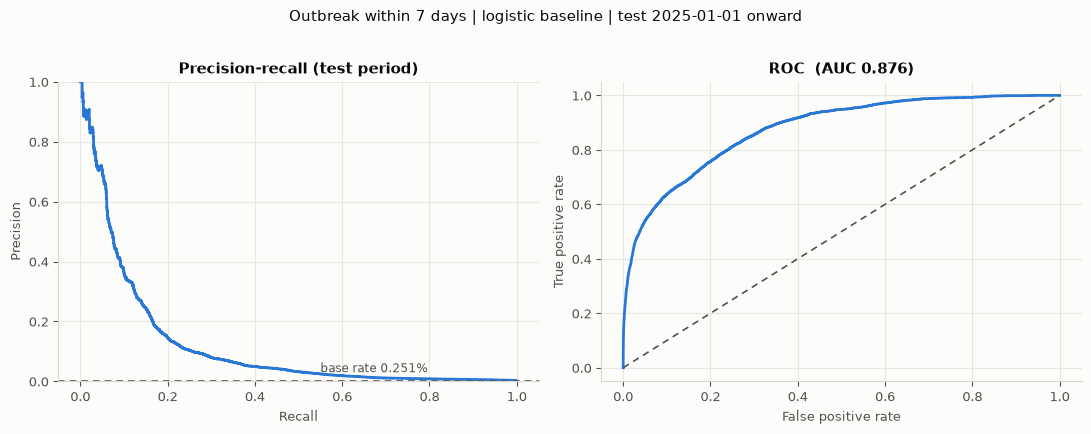

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

prec, rec, _ = precision_recall_curve(y_te, p_te)
axes[0].plot(rec, prec, color=BLUE)
axes[0].axhline(base_rate, color=INK_2, lw=1.2, ls=(0, (4, 3)))
axes[0].annotate(f"base rate {base_rate:.3%}", (0.55, base_rate), textcoords="offset points",
                 xytext=(0, 6), color=INK_2, fontsize=8.5)
axes[0].set(xlabel="Recall", ylabel="Precision", ylim=(0, 1),
            title="Precision-recall (test period)")

fpr, tpr, _ = roc_curve(y_te, p_te)
axes[1].plot(fpr, tpr, color=BLUE)
axes[1].plot([0, 1], [0, 1], color=INK_2, lw=1.2, ls=(0, (4, 3)))
axes[1].set(xlabel="False positive rate", ylabel="True positive rate",
            title=f"ROC  (AUC {roc_auc_score(y_te, p_te):.3f})")

fig.suptitle(f"Outbreak within 7 days | logistic baseline | test {SPLIT_DATE} onward",
             fontsize=10.5, color=INK, y=1.02)
fig.tight_layout()
plt.show()

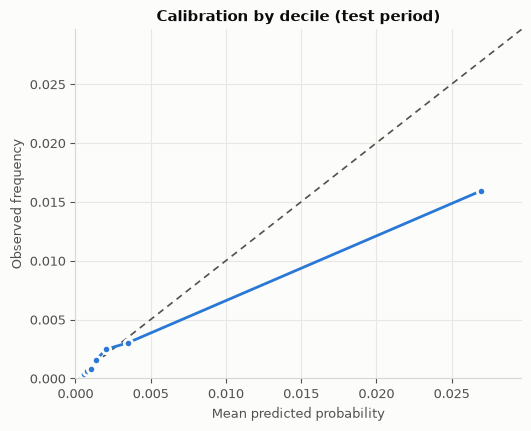

,pred,obs,n
bin,,,
0,0.0194%,0.0023%,174048
1,0.0325%,0.0161%,174048
2,0.0446%,0.0115%,174048
3,0.0586%,0.0402%,174048
4,0.0765%,0.0603%,174048
5,0.1010%,0.0776%,174048
6,0.1379%,0.1580%,174048
7,0.2032%,0.2465%,174048
8,0.3508%,0.3034%,174048


In [10]:
# --- calibration: decile bins of predicted probability vs observed frequency ---
cal = pd.DataFrame({"p": p_te, "y": y_te.values})
cal["bin"] = pd.qcut(cal.p, 10, labels=False, duplicates="drop")
g = cal.groupby("bin").agg(pred=("p", "mean"), obs=("y", "mean"), n=("y", "size"))

fig, ax = plt.subplots(figsize=(5.4, 4.4))
lim = max(g.pred.max(), g.obs.max()) * 1.1
ax.plot([0, lim], [0, lim], color=INK_2, lw=1.2, ls=(0, (4, 3)))
ax.plot(g.pred, g.obs, color=BLUE, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=2)
ax.set(xlabel="Mean predicted probability", ylabel="Observed frequency",
       title="Calibration by decile (test period)", xlim=(0, lim), ylim=(0, lim))
fig.tight_layout()
plt.show()

display(g.assign(pred=lambda d: d.pred.map("{:.4%}".format),
                 obs=lambda d: d.obs.map("{:.4%}".format)))

## 5. Inference — coefficients with county-clustered standard errors

`sklearn` gives no standard errors, and naive ones would be badly overconfident here: ~1,600
observations per county are anything but independent draws. Refit with `statsmodels` and cluster
the covariance by `fips`, so the standard errors reflect roughly the number of *counties*, not the
number of county-days.

Fitted on the **training window only**, so the test period stays untouched for evaluation.

In [11]:
Xs = (X_tr - X_tr.mean()) / X_tr.std().replace(0, 1)   # standardized -> comparable ORs
Xs = sm.add_constant(Xs, has_constant="add")

# Discrete models take cov_type in fit() itself -- get_robustcov_results() is an
# OLS/GLM-only method and raises AttributeError on a LogitResults object.
res = sm.Logit(y_tr.values, Xs).fit(
    disp=False, method="lbfgs", maxiter=200,
    cov_type="cluster", cov_kwds={"groups": df.loc[train, "fips"].values},
)

ci = np.asarray(res.conf_int())    # DataFrame when the design matrix is a DataFrame
coef = pd.DataFrame({
    "odds_ratio": np.exp(np.asarray(res.params)),
    "ci_low":     np.exp(ci[:, 0]),
    "ci_high":    np.exp(ci[:, 1]),
    "p_value":    np.asarray(res.pvalues),
}, index=Xs.columns)
coef["significant"] = coef.p_value < 0.05
coef = coef.drop("const").sort_values("odds_ratio", ascending=False)

print("Odds ratio per 1 SD increase. Clustered by county (n_clusters = "
      f"{df.loc[train, 'fips'].nunique():,}).\n")
display(coef.head(12).style.format(
    {"odds_ratio": "{:.3f}", "ci_low": "{:.3f}", "ci_high": "{:.3f}", "p_value": "{:.2e}"}))

Odds ratio per 1 SD increase. Clustered by county (n_clusters = 3,108).



,odds_ratio,ci_low,ci_high,p_value,significant
log_poultry_operations,1.541,0.964,2.462,7.05e-02,False
log_turkey_operations,1.432,1.257,1.630,5.82e-08,True
log_population,1.299,1.172,1.441,6.59e-07,True
log_breeding_side_pressure,1.272,1.209,1.338,1.67e-20,True
log_wintering_side_pressure,1.250,1.188,1.317,1.96e-17,True
log_layer_inventory,1.183,1.056,1.325,3.64e-03,True
log_own_outbreaks_7d,1.158,1.111,1.206,1.93e-12,True
days_since_outbreak_county,1.147,1.013,1.300,3.07e-02,True
log_own_outbreaks_21d,1.135,1.070,1.205,3.02e-05,True
log_nbr_infected_counties_21d,1.108,0.943,1.302,2.12e-01,False


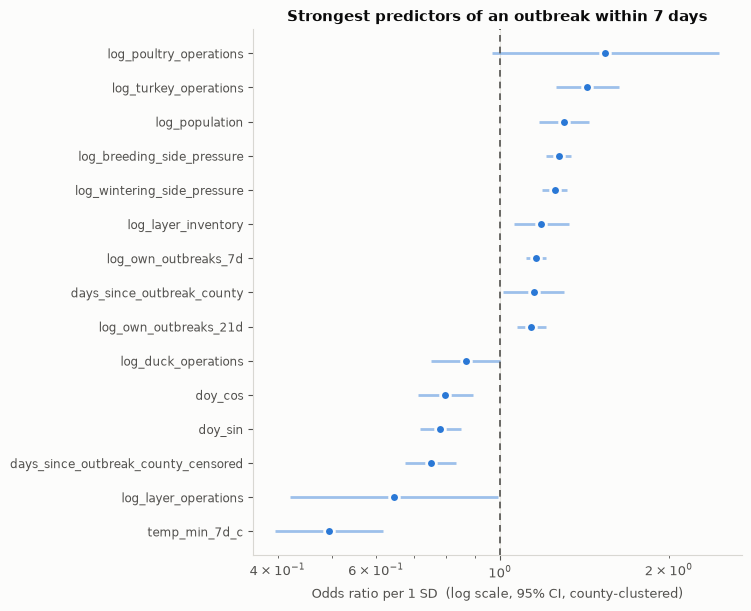

In [12]:
top = pd.concat([coef.head(9), coef.tail(6)]).sort_values("odds_ratio")
fig, ax = plt.subplots(figsize=(7.6, 6.2))
ypos = np.arange(len(top))

ax.hlines(ypos, top.ci_low, top.ci_high, color=BLUE, lw=2, alpha=0.45)
ax.plot(top.odds_ratio, ypos, "o", color=BLUE, markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=2, linestyle="none")
ax.axvline(1.0, color=INK_2, lw=1.2, ls=(0, (4, 3)))

ax.set_yticks(ypos)
ax.set_yticklabels(top.index, fontsize=8.5)
ax.set_xscale("log")
ax.set(xlabel="Odds ratio per 1 SD  (log scale, 95% CI, county-clustered)",
       title="Strongest predictors of an outbreak within 7 days")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 6. What this is and is not

**Is:** an honest, leakage-checked, temporally-split baseline with population-valid test metrics —
the reference number that sentiment has to beat.

**Is not:** a tuned model. Deliberately absent, in rough order of expected payoff:

1. **No regularization path or nonlinear model.** A gradient-boosted tree will almost certainly
   beat this; logistic regression was chosen because its coefficients are interpretable and its
   failure modes are visible.
2. **No spatial random effect.** Clustered standard errors fix the *inference*, not the *fit* —
   counties still enter as independent rows.
3. **`own_outbreaks_*` probably dominates.** An already-infected county staying infected is real
   signal but a weak early-warning claim. Re-run with those columns dropped to see what the
   environmental and spatial features carry on their own.
4. **Banding features excluded** (`INCLUDE_BANDING = False`) because `fact_bird_density` ends
   2025-07-10, inside the test window.
5. **No permutation control yet.** The project's methodological control — shuffling a feature block
   and confirming performance degrades — is the natural next cell, and is what will make the
   eventual sentiment claim credible.
6. **Poultry exposure is a static 2022 snapshot** applied across 2022–2026, so it cannot reflect
   depopulation and restocking caused by the very outbreaks being modeled.

# Iterate Testing With Various Angles and Distances of the Breeding Pressure 



## Testing Range
In the previous logistic regression, we used the breeding/wintering side pressure at the Angle of SECTOR_HALF_WIDTH_DEG = 45, Distance at the Radius_km = 300, and DECAY_SCALE_KM = 150 or 1/2 of the distance. 
We are going to test with other angle/distance/decay values and compared to the precision-recall and ROC scores. 

| Variables | Range | Testing Range |
|-----------|-------|---------------|
| Angle | [0 degree, 180 degree]|[0,45,90,135,180]|
| Distance | [0 km, 400 km]|[0,100,200,300,400]|
| Decay scale | No limit weight = exp(-distance_km / DECAY_SCALE_KM))|[1/2, 1/3, 1/4, 1/5, 1/6] of distance|

## How to execute editing Angle, Distance, and Decay?
select raw tables county_proximity, county_migration_axis, fact_wild_bird_detection -> re-implement angle, distance, and angle on the notebook -> intergrate it to current df -> run logistic regression -> store the testing values.

## What are the Benchmark or Measuring Values

|Recording Measurements|Definition|
|----------------------|----------|
|Precision| (TP/(TP+FP))|
|Recall| (TP/(TP+FN))|
|PR-AUC| The area under the precision-recall curve|
|ROC-AUC| The area under the True positive vs False positive rate curve|
|PR base rate| Percent of Positive in the data|
|lift| PR-AUC/base rate|

In [29]:
df_without_side_pressure = df.drop(columns=['breeding_side_pressure','wintering_side_pressure'])

In [28]:
# --- read-only pulls: the raw geometry + detections behind migration pressure -----
# feature_county_day only has the ALREADY-BUILT breeding_side_pressure /
# wintering_side_pressure -- computed once, offline, by
# h5n1/features/migration_pressure.py with its own fixed constants (45 deg / 300 km /
# 150 km / 21 days) and upserted into feature_migration_pressure. To try other
# angles/radii/decay scales here we rebuild the feature LOCALLY from the raw tables
# below. Every query is a plain SELECT -- nothing is written back to the database.
from sqlalchemy import text

from h5n1.sources.migration import angular_diff

with get_engine().connect() as conn:
    prox_raw = pd.DataFrame(
        conn.execute(text(
            "SELECT fips, neighbor_fips, distance_km, bearing_deg FROM county_proximity"
        )).all(),
        columns=["fips", "neighbor_fips", "distance_km", "bearing_deg"],
    )
    axis_raw = pd.DataFrame(
        conn.execute(text(
            "SELECT fips, breeding_bearing_deg, wintering_bearing_deg FROM county_migration_axis"
        )).all(),
        columns=["fips", "breeding_bearing_deg", "wintering_bearing_deg"],
    )
    det_raw = pd.DataFrame(
        conn.execute(text(
            "SELECT fips, day, detection_count FROM fact_wild_bird_detection"
        )).all(),
        columns=["fips", "day", "detection_count"],
    )

print(f"county_proximity          {len(prox_raw):,} directed pairs (stored out to 400 km)")
print(f"county_migration_axis     {len(axis_raw):,} counties")
print(f"fact_wild_bird_detection  {len(det_raw):,} county-days")

county_proximity          787,620 directed pairs (stored out to 400 km)
county_migration_axis     3,108 counties
fact_wild_bird_detection  8,465 county-days


In [30]:
# --- local, parameterized reimplementation of h5n1/features/migration_pressure.py ---
# Identical math to the production module, but sector_half_width_deg / radius_km /
# decay_scale_km / lag_days are function ARGUMENTS instead of module constants, so
# different values can be swept here without touching the DB or feature_migration_pressure.
# Production defaults: 45 deg / 300 km / 150 km / 21 days.
#
# Hard bounds (see h5n1/features/migration_pressure.py and sql/seed_migration.py):
#   sector_half_width_deg in [0, 180]  -- angular_diff() is confined to that range;
#                                          180 = no directional filter at all
#   radius_km             in [0, 400]  -- county_proximity is only stored out to
#                                          R_MAX_KM = 400 km; past 400 needs re-seeding
#   decay_scale_km        >= 0         -- no stored cap; radius_km == 0 yields zero
#                                          pressure regardless of decay (no edges pass
#                                          the distance filter, so no division ever runs)

LAG_DAYS_DEFAULT = 21


def sector_edges(prox, axis, bearing_col, sector_half_width_deg, radius_km, decay_scale_km):
    e = prox.merge(axis[["fips", bearing_col]], on="fips")
    e = e[e["distance_km"] <= radius_km]
    e = e[angular_diff(e["bearing_deg"], e[bearing_col]) <= sector_half_width_deg]
    e = e.assign(weight=np.exp(-e["distance_km"] / decay_scale_km))
    return e[["fips", "neighbor_fips", "weight"]]


def side_pressure(edges, det, lag_days):
    j = edges.merge(det, left_on="neighbor_fips", right_on="fips", suffixes=("", "_src"))
    j["contrib"] = j["weight"] * j["detection_count"]
    daily = j.groupby(["fips", "day"], as_index=False)["contrib"].sum()  # (C, d', value)

    # spread each source day d' across the trailing window: it feeds days d'+1 .. d'+lag_days
    spread = [
        daily.assign(day=pd.to_datetime(daily["day"]) + pd.Timedelta(days=k))
        for k in range(1, lag_days + 1)
    ]
    s = pd.concat(spread, ignore_index=True)
    return s.groupby(["fips", "day"], as_index=False)["contrib"].sum()


def build_side_pressure(bearing_col, sector_half_width_deg, radius_km, decay_scale_km,
                         lag_days=LAG_DAYS_DEFAULT):
    edges = sector_edges(prox_raw, axis_raw, bearing_col, sector_half_width_deg, radius_km, decay_scale_km)
    return side_pressure(edges, det_raw, lag_days)

In [31]:
# --- rebuild breeding/wintering_side_pressure for one (angle, radius, decay) combo ---
# --- and splice them onto df_without_side_pressure (every other column untouched) ---
def with_side_pressure(sector_half_width_deg, radius_km, decay_scale_km, lag_days=LAG_DAYS_DEFAULT):
    bp = build_side_pressure("breeding_bearing_deg", sector_half_width_deg, radius_km, decay_scale_km, lag_days)
    bp = bp.rename(columns={"contrib": "breeding_side_pressure"})
    wp = build_side_pressure("wintering_bearing_deg", sector_half_width_deg, radius_km, decay_scale_km, lag_days)
    wp = wp.rename(columns={"contrib": "wintering_side_pressure"})

    out = df_without_side_pressure.merge(bp, on=["fips", "day"], how="left")
    out = out.merge(wp, on=["fips", "day"], how="left")
    # no row in bp/wp for a (fips, day) means zero weighted detections reached it in the
    # trailing window -- genuinely zero, not missing, same convention as the production table
    out["breeding_side_pressure"] = out["breeding_side_pressure"].fillna(0.0)
    out["wintering_side_pressure"] = out["wintering_side_pressure"].fillna(0.0)
    return out

In [32]:
# --- reuse the SAME feature-prep and fit/score logic as sections 2-3 above, but as ---
# --- functions, so each side-pressure variant can be scored without retyping it -----
def build_X(frame):
    Xv = pd.DataFrame(index=frame.index)

    for c in COUNT_COLS:
        Xv[f"log_{c}"] = np.log1p(frame[c].clip(lower=0))

    for c in ["days_since_outbreak_county", "days_since_outbreak_neighbor"]:
        Xv[f"{c}_censored"] = frame[c].isna().astype(int)
        Xv[c] = frame[c].fillna(400) / 100.0

    Xv["layer_inventory_suppressed"] = (frame.layer_inventory.isna() & (frame.layer_operations > 0)).astype(int)
    Xv["log_layer_inventory"] = np.log1p(frame.layer_inventory.fillna(frame.layer_inventory.median()))

    if INCLUDE_BANDING:
        Xv["log_band_count_21d"] = np.log1p(frame.band_count_21d.clip(lower=0))
        Xv["log_nbr_band_count_21d"] = np.log1p(frame.nbr_band_count_21d.clip(lower=0))

    for c in PASSTHROUGH:
        Xv[c] = frame[c]

    Xv["weather_missing"] = frame.temp_max_7d_c.isna().astype(int)
    for c in ["temp_min_7d_c", "temp_max_7d_c", "precip_7d_mm"]:
        Xv[c] = Xv[c].fillna(Xv.loc[frame.day < SPLIT_DATE, c].median())

    return Xv


def fit_and_score(frame, label):
    """Same temporal split, same case-control intercept correction, same metrics as above."""
    Xv = build_X(frame)
    yv = frame.target_outbreak_next_7d.astype(int)
    trainv, testv = frame.day < SPLIT_DATE, frame.day >= SPLIT_DATE

    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE))
    m.fit(Xv[trainv], yv[trainv])
    m.named_steps["logisticregression"].intercept_ += np.log(NEG_SAMPLE_RATE)

    p = m.predict_proba(Xv[testv])[:, 1]
    y_te_v = yv[testv]
    base = y_te_v.mean()
    pr = average_precision_score(y_te_v, p)

    return {
        "label": label,
        "PR_AUC": pr,
        "ROC_AUC": roc_auc_score(y_te_v, p),
        "base_rate": base,
        "lift": pr / base,
    }

In [38]:
# --- one-factor-at-a-time sweep over the Testing Range table above ------------------
# Each parameter is varied in turn while the other two stay at the production defaults
# (45 deg / 300 km / 150 km) -- 15 model fits total instead of the 5x5x5=125 a full
# factorial would need. Extend this into a nested loop if a full grid is wanted later.
# Each fit refits logistic regression from scratch (~10-60s depending on machine), so
# this cell takes a few minutes to run.
PRODUCTION_ANGLE, PRODUCTION_RADIUS, PRODUCTION_DECAY = 45.0, 300.0, 150.0  # decay = 1/2 radius

ANGLES          = [0, 5, 10, 20, 30, 45, 90, 135, 180]
DISTANCES       = [0, 20, 40, 60, 80, 100, 200, 300, 400]
DECAY_FRACTIONS = [9/10, 8/10, 7/10, 6/10,1 / 2, 1 / 3, 1 / 4, 1 / 5, 1 / 6]   # of PRODUCTION_RADIUS

results = []

for angle in ANGLES:
    frame = with_side_pressure(angle, PRODUCTION_RADIUS, PRODUCTION_DECAY)
    r = fit_and_score(frame, f"angle={angle:g} deg")
    r.update(sweep="angle", angle_deg=angle, radius_km=PRODUCTION_RADIUS, decay_km=PRODUCTION_DECAY)
    results.append(r)
    print(f"angle={angle:>3g} deg   PR-AUC={r['PR_AUC']:.4f}  ROC-AUC={r['ROC_AUC']:.4f}  lift={r['lift']:.1f}x")

for radius in DISTANCES:
    decay = radius * 0.5   # hold decay at 1/2 radius as radius moves, matching the production ratio
    frame = with_side_pressure(PRODUCTION_ANGLE, radius, decay)
    r = fit_and_score(frame, f"radius={radius:g} km")
    r.update(sweep="radius", angle_deg=PRODUCTION_ANGLE, radius_km=radius, decay_km=decay)
    results.append(r)
    print(f"radius={radius:>3g} km   PR-AUC={r['PR_AUC']:.4f}  ROC-AUC={r['ROC_AUC']:.4f}  lift={r['lift']:.1f}x")

for frac in DECAY_FRACTIONS:
    decay = PRODUCTION_RADIUS * frac
    frame = with_side_pressure(PRODUCTION_ANGLE, PRODUCTION_RADIUS, decay)
    r = fit_and_score(frame, f"decay={decay:.0f} km ({frac:.3g} of radius)")
    r.update(sweep="decay", angle_deg=PRODUCTION_ANGLE, radius_km=PRODUCTION_RADIUS, decay_km=decay)
    results.append(r)
    print(f"decay={decay:>6.1f} km   PR-AUC={r['PR_AUC']:.4f}  ROC-AUC={r['ROC_AUC']:.4f}  lift={r['lift']:.1f}x")

results_df = pd.DataFrame(results)[
    ["sweep", "angle_deg", "radius_km", "decay_km", "base_rate", "PR_AUC", "ROC_AUC", "lift"]
]
results_df

angle=  0 deg   PR-AUC=0.1205  ROC-AUC=0.8751  lift=48.0x
angle=  5 deg   PR-AUC=0.1184  ROC-AUC=0.8756  lift=47.2x
angle= 10 deg   PR-AUC=0.1170  ROC-AUC=0.8757  lift=46.7x
angle= 20 deg   PR-AUC=0.1173  ROC-AUC=0.8763  lift=46.8x
angle= 30 deg   PR-AUC=0.1148  ROC-AUC=0.8768  lift=45.8x
angle= 45 deg   PR-AUC=0.1136  ROC-AUC=0.8761  lift=45.3x
angle= 90 deg   PR-AUC=0.1143  ROC-AUC=0.8769  lift=45.6x
angle=135 deg   PR-AUC=0.1191  ROC-AUC=0.8763  lift=47.5x
angle=180 deg   PR-AUC=0.1188  ROC-AUC=0.8755  lift=47.4x
radius=  0 km   PR-AUC=0.1205  ROC-AUC=0.8751  lift=48.0x
radius= 20 km   PR-AUC=0.1193  ROC-AUC=0.8752  lift=47.6x
radius= 40 km   PR-AUC=0.1206  ROC-AUC=0.8752  lift=48.1x
radius= 60 km   PR-AUC=0.1209  ROC-AUC=0.8751  lift=48.2x
radius= 80 km   PR-AUC=0.1206  ROC-AUC=0.8750  lift=48.1x
radius=100 km   PR-AUC=0.1198  ROC-AUC=0.8756  lift=47.7x
radius=200 km   PR-AUC=0.1156  ROC-AUC=0.8769  lift=46.1x
radius=300 km   PR-AUC=0.1136  ROC-AUC=0.8761  lift=45.3x
radius=400 km 

,sweep,angle_deg,radius_km,decay_km,base_rate,PR_AUC,ROC_AUC,lift
0,angle,0.0,300.0,150.0,0.002509,0.120516,0.875062,48.042900
1,angle,5.0,300.0,150.0,0.002509,0.118364,0.875603,47.185075
2,angle,10.0,300.0,150.0,0.002509,0.117026,0.875665,46.651796
3,angle,20.0,300.0,150.0,0.002509,0.117338,0.876284,46.775951
4,angle,30.0,300.0,150.0,0.002509,0.114847,0.876778,45.782981
5,angle,45.0,300.0,150.0,0.002509,0.113590,0.876087,45.281968
6,angle,90.0,300.0,150.0,0.002509,0.114303,0.876854,45.566262
7,angle,135.0,300.0,150.0,0.002509,0.119087,0.876250,47.473283
8,angle,180.0,300.0,150.0,0.002509,0.118848,0.875453,47.378128
9,radius,45.0,0.0,0.0,0.002509,0.120516,0.875062,48.042900


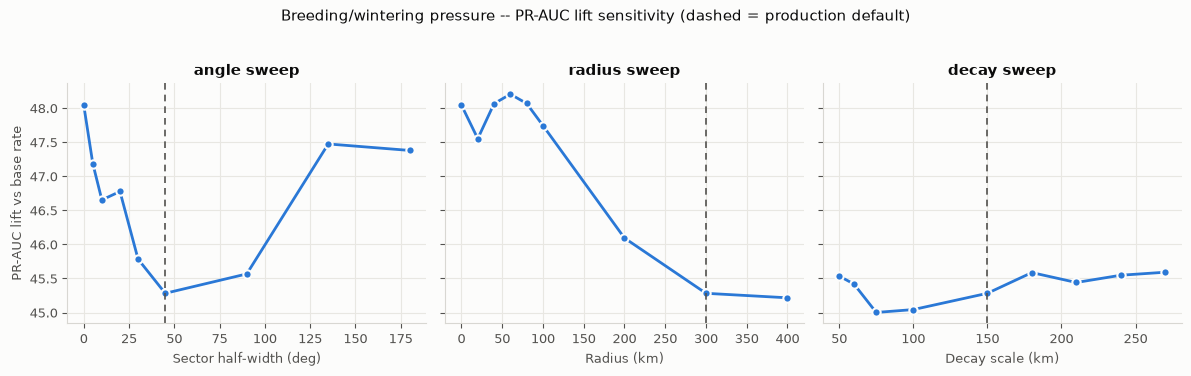

In [39]:
# --- visualize: PR-AUC lift as each parameter moves away from the production default ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
sweep_specs = [
    ("angle",  "angle_deg",  "Sector half-width (deg)", PRODUCTION_ANGLE),
    ("radius", "radius_km",  "Radius (km)",              PRODUCTION_RADIUS),
    ("decay",  "decay_km",   "Decay scale (km)",         PRODUCTION_DECAY),
]
for ax, (sweep_name, xcol, xlabel, prod_val) in zip(axes, sweep_specs):
    sub = results_df[results_df.sweep == sweep_name].sort_values(xcol)
    ax.plot(sub[xcol], sub.lift, color=BLUE, marker="o", markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.axvline(prod_val, color=INK_2, lw=1.2, ls=(0, (4, 3)))
    ax.set(xlabel=xlabel, title=f"{sweep_name} sweep")

axes[0].set_ylabel("PR-AUC lift vs base rate")
fig.suptitle("Breeding/wintering pressure -- PR-AUC lift sensitivity (dashed = production default)",
             fontsize=10.5, color=INK, y=1.03)
fig.tight_layout()
plt.show()

## Interpretation of angle, radius, and decay sweep

<u>Angles</u>
We start with high PR-AUC/base rate at zero degrees, but it is possible within the number range-wise. When we think about it realistically, there will be no neighbors considered at all, and it is behaving as if removing the neighbor county as a feature. Also, the migration axis is a float, and it is very rare to match the migration axis to the county location axis, since county centroids span multiple axes. 
There is a decrease in PR-AUC/base rate until it hits 45 degrees, and then the rate increases and peaks at 135 degrees. 

<u>Radius</u>
The radius graph shows a very interesting trend, which is that the shortest radius distances have a high PR-AUC/base rate that peaks at 60 degrees. Then it decreases at that rate after that.

<u>Decay</u>
For the decay sweep, it decreases from 1/6 and then increases in trend and peaks at 6/10.  